In [1]:
#Uploading CSV file to Google Colab

from google.colab import files
import io
import pandas as pd

uploaded = files.upload()



Saving customer_churn_nn.csv to customer_churn_nn.csv


# **Task 1: Dataset Understanding**

In [2]:
# Load dataset
df = pd.read_csv("customer_churn_nn.csv")

In [3]:
# 1. Number of rows and columns

print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape:
(2000, 17)

Number of Rows: 2000
Number of Columns: 17


In [4]:
# 2. Type of input features

print("\nData Types of Features:")
print(df.dtypes)


Data Types of Features:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [5]:
# 3. Target variable description

print("\nTarget Variable: churn")
print("0 = Customer stayed")
print("1 = Customer left (churned)")

print("\nTarget Variable Distribution:")
print(df["churn"].value_counts())


Target Variable: churn
0 = Customer stayed
1 = Customer left (churned)

Target Variable Distribution:
churn
0    1969
1      31
Name: count, dtype: int64


In [6]:
# 4. Missing value check

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [7]:
# 5. Basic statistical summary

print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000       

In [8]:
# 6. Distribution of target variable

print("\nChurn Distribution Percentage:")
print(df["churn"].value_counts(normalize=True) * 100)


Churn Distribution Percentage:
churn
0    98.45
1     1.55
Name: proportion, dtype: float64



# **Task 2: Data Preprocessing**

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [13]:
# 1. Handling Missing Values

print("Missing Values Before Handling:\n")
print(df.isnull().sum())

# No missing values found

Missing Values Before Handling:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [14]:
# 2. Encoding Categorical Columns

label_encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoded Dataset Preview:\n")
print(df.head())



Encoded Dataset Preview:

   customer_id  region  plan_type  contract_type  payment_method  \
0            0       3          3              0               1   
1            1       4          2              0               4   
2            2       0          3              0               0   
3            3       4          2              0               0   
4            4       2          2              0               2   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                    

In [16]:
# 3. Splitting Features and Target

X = df.drop("churn", axis=1)
y = df["churn"]


In [17]:
# 4. Scaling Numerical Features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
# 5. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Set Shape:")
print(X_train.shape)

print("\nTesting Set Shape:")
print(X_test.shape)


Training Set Shape:
(1600, 16)

Testing Set Shape:
(400, 16)


# **Task 3: Neural Network Model Building**

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [27]:
# Building the model

model = Sequential()

# Input Layer + Hidden Layer
model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))

# Second Hidden Layer
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compiling the model

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nNeural Network Model Summary:\n")
model.summary()



Neural Network Model Summary:



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

# **Task 4: Training and Evaluation**

In [28]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate

loss, acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", acc)
print("Test Loss:", loss)

# Confusion matrix

from sklearn.metrics import confusion_matrix, classification_report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7867 - loss: 0.4888 - val_accuracy: 0.9406 - val_loss: 0.3113
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9766 - loss: 0.2316 - val_accuracy: 0.9781 - val_loss: 0.1909
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1437 - val_accuracy: 0.9781 - val_loss: 0.1450
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1080 - val_accuracy: 0.9781 - val_loss: 0.1256
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0912 - val_accuracy: 0.9781 - val_loss: 0.1170
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0822 - val_accuracy: 0.9781 - val_loss: 0.1119
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0763 - val_accuracy: 0.9781 - val_loss: 0.1064
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0717 - val_accuracy: 0.9781 - val_loss:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


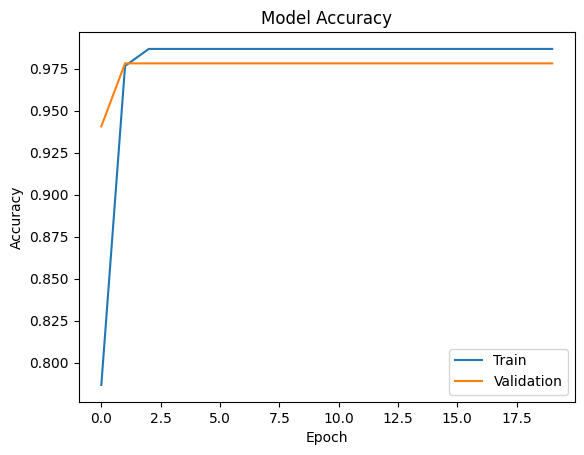

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import matplotlib.pyplot as plt

# Accuracy Graph

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.savefig("evaluation_outputs.png")

plt.show()

# Saving graph in local system

from google.colab import files
files.download('evaluation_outputs.png')

**Brief Interpretation of Result**

The model achieves high overall accuracy (98%) because almost all customers are non‑churn. It correctly predicts every non‑churn case but fails to identify any actual churners. Precision, recall, and F1 for class 1 (churn) are all zero, showing the model completely misses the churn class. Despite the high accuracy, the model is ineffective for churn prediction due to class imbalance.

# **Task 5: Hyperparameter Experimentation**

In [37]:
results = []

def run_experiment(neurons=32, learning_rate=0.001, epochs=20, batch=32, activation='relu'):

    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_dim=X_train.shape[1]))
    model.add(Dense(neurons//2, activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return acc, loss

In [38]:
# Experiment 1

acc1, loss1 = run_experiment(
    neurons=16,
    learning_rate=0.001,
    epochs=20,
    batch=32,
    activation='relu'
)

# Experiment 2

acc2, loss2 = run_experiment(
    neurons=32,
    learning_rate=0.001,
    epochs=30,
    batch=16,
    activation='relu'
)

# Experiment 3

acc3, loss3 = run_experiment(
    neurons=64,
    learning_rate=0.0005,
    epochs=40,
    batch=64,
    activation='tanh'
)

# Comparison Table

import pandas as pd

results = pd.DataFrame({
    "Experiment": ["Experiment 1", "Experiment 2", "Experiment 3"],
    "Hidden Layers": ["16, 8", "32, 16", "64, 32"],
    "Activation": ["ReLU", "ReLU", "Tanh"],
    "Learning Rate": [0.001, 0.001, 0.0005],
    "Batch Size": [32, 16, 64],
    "Epochs": [20, 30, 40],
    "Test Accuracy": [acc1, acc2, acc3],
    "Test Loss": [loss1, loss2, loss3]
})

print("\nHyperparameter Experiment Results:\n")
print(results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Hyperparameter Experiment Results:

     Experiment Hidden Layers Activation  Learning Rate  Batch Size  Epochs  \
0  Experiment 1         16, 8       ReLU         0.0010          32      20   
1  Experiment 2        32, 16       ReLU         0.0010          16      30   
2  Experiment 3        64, 32       Tanh         0.0005          64      40   

   Test Accuracy  Test Loss  
0         0.9825   0.073299  
1         0.9750   0.132634  
2         0.9800   0.071335  


**Brief interpretation:** Experiment 1 achieved the best overall balance, with the highest accuracy and low loss, indicating a stable model. Experiment 2 performed slightly worse, suggesting that increasing batch size and epochs did not improve learning and may have introduced some instability. Experiment 3 performed nearly as well as Experiment 1, showing that more neurons and the tanh activation helped learning but did not significantly outperform simpler configurations. Overall, all models behaved similarly, with only small performance differences.

# **Task 6: Final Reflection**

### 1. **Role of Weights and Biases**
Weights and biases are the parameters the neural network learns during training.

*   **Weights** control how much influence each input has on the prediction.
*   **Biases** help the model make better decisions by shifting the activation function.

Together, they help the model learn patterns in the data.
### 2. **Why Activation Function?**
Activation functions introduce non‑linearity. Without them, the model could only learn simple straight‑line relationships. Real‑world problems like customer churn have complex patterns, so activation functions help the model capture those patterns.
### 3. **Effect of Learning Rate**
- **Too high:** The model jumps around and cannot settle on good values; training becomes unstable.  
- **Too low:** The model learns extremely slowly and may never reach a good solution.
### 4. **Underfitting / Overfitting Observation**
Underfitting occurs when both training and testing accuracy are low, meaning the model is too simple to learn the data patterns.

Overfitting occurs when training accuracy is very high but testing accuracy is much lower, meaning the model memorized the training data instead of generalizing well.

The model did not show major overfitting because the test accuracy was close to the training accuracy. However, it struggled with predicting the minority class (churn), which suggests it didn’t learn enough about that class - this is more related to **class imbalance** than overfitting.